In [18]:
# Install missingno if you haven't yet
try:
    import missingno as msno
except ImportError:
    !pip install missingno
    import missingno as msno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [19]:
# The '..' moves up one folder before looking for 'data'
df = pd.read_csv('../data/raw/groceries.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 38006 rows and 7 columns.


In [20]:
# Check for missing values
missing = df.isnull().sum()
print("=== Missing Values Report ===")
print(missing)

# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Note: In Phase 3 (Preparation), we will handle these duplicates.
if duplicates > 0:
    print("\nSample of duplicate rows found. These will be removed in the next phase.")

=== Missing Values Report ===
Member_number      0
Date               0
itemDescription    0
Day                0
Day_Name           0
Month              0
Is_Weekend         0
dtype: int64

Number of duplicate rows: 0


DATASET DIMENSIONS
Total Observations (Rows): 38006
Total Variables (Columns): 7
Total Data Points: 266042


<Figure size 1200x700 with 0 Axes>

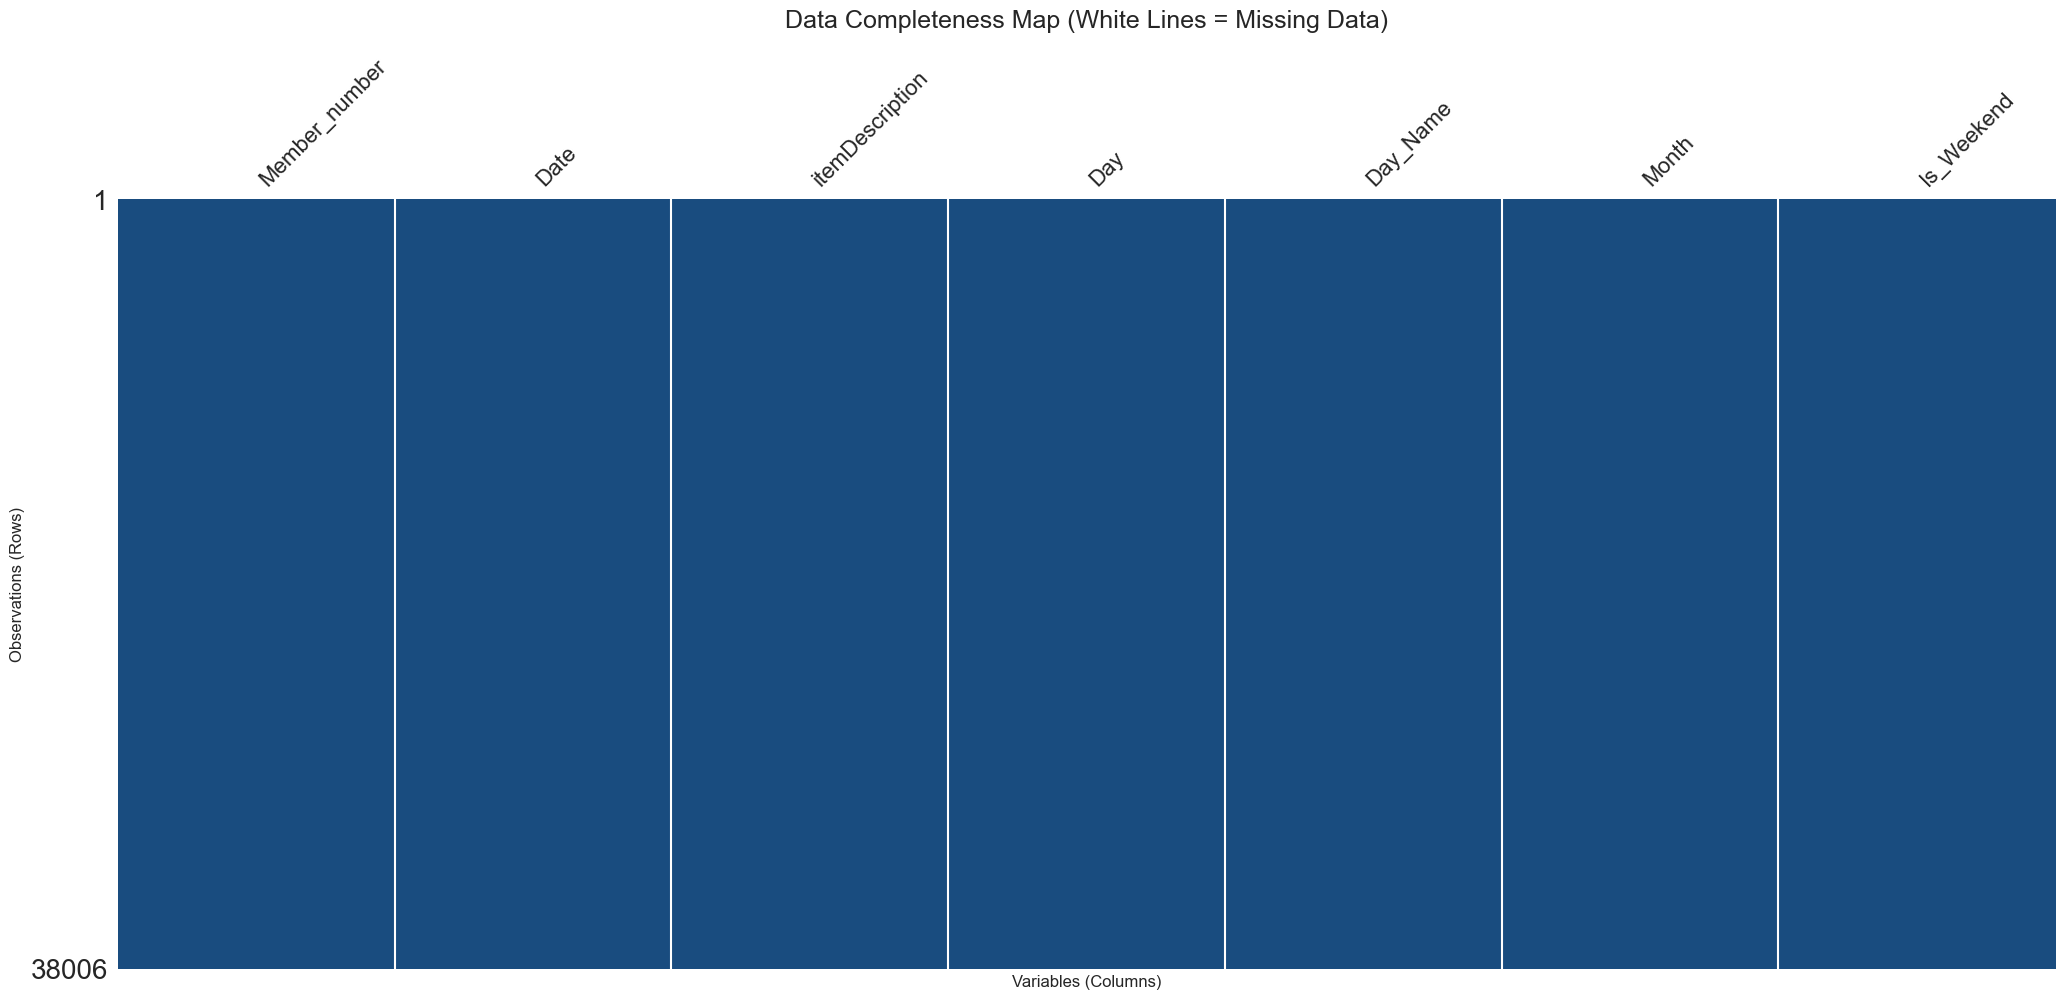

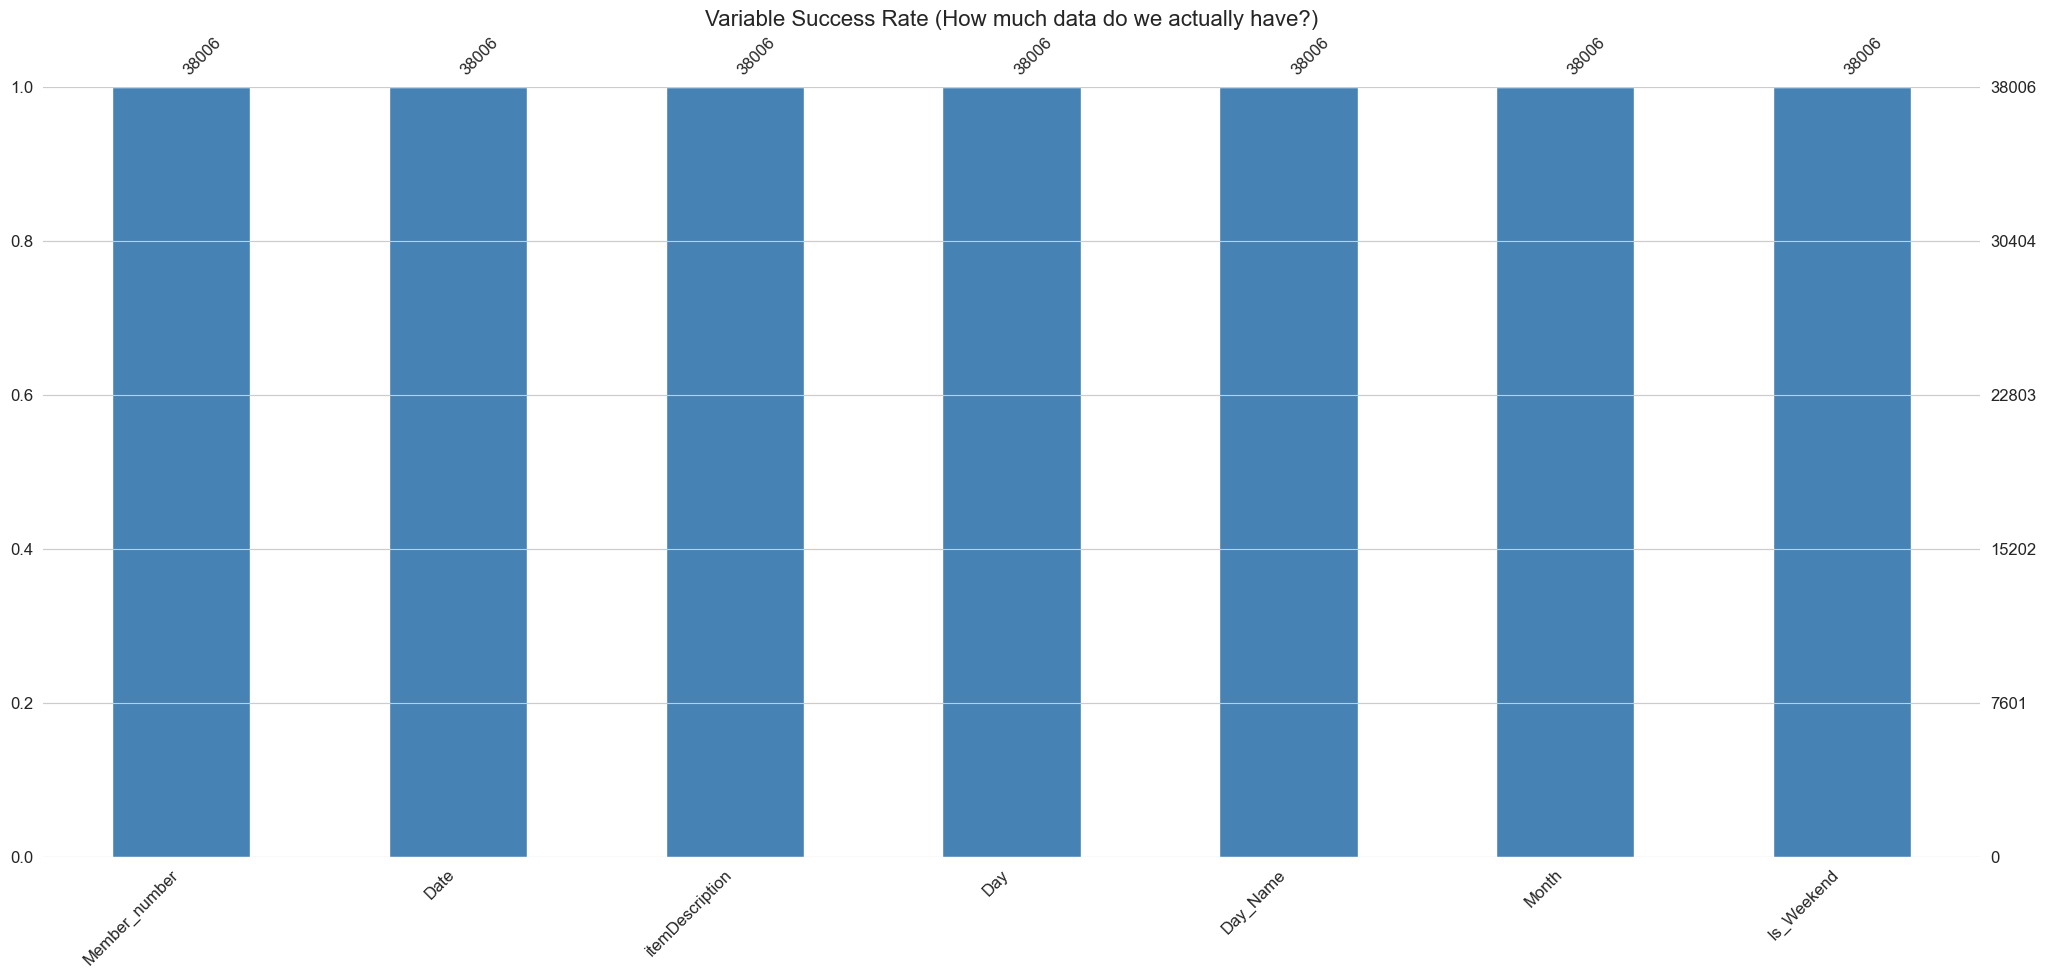

In [21]:
# --- Task 2: Describe Data (The Data Quality Dashboard) ---

# 1. Summary Statistics & Dimensions
print("="*30)
print("DATASET DIMENSIONS")
print("="*30)
print(f"Total Observations (Rows): {df.shape[0]}")
print(f"Total Variables (Columns): {df.shape[1]}")
print(f"Total Data Points: {df.size}")

# 2. Visualizing the "Veracity" (Missing Data Map)
import missingno as msno

# Plot A: The Matrix Map
# This shows you the location of every missing value. 
# Think of it as an X-ray of your dataset.
plt.figure(figsize=(12, 7))
msno.matrix(df, sparkline=False, color=(0.1, 0.3, 0.5))
plt.title("Data Completeness Map (White Lines = Missing Data)", fontsize=18, pad=20)
plt.xlabel("Variables (Columns)", fontsize=12)
plt.ylabel("Observations (Rows)", fontsize=12)
plt.show()

# Plot B: The Bar Chart (Percentage View)
# This is used to quickly identify which columns are failing.
plt.figure(figsize=(12, 5))
msno.bar(df, color="steelblue", fontsize=12)
plt.title("Variable Success Rate (How much data do we actually have?)", fontsize=16)
plt.show()

/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_18673/511395157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index, y=top_items.values, palette='magma')


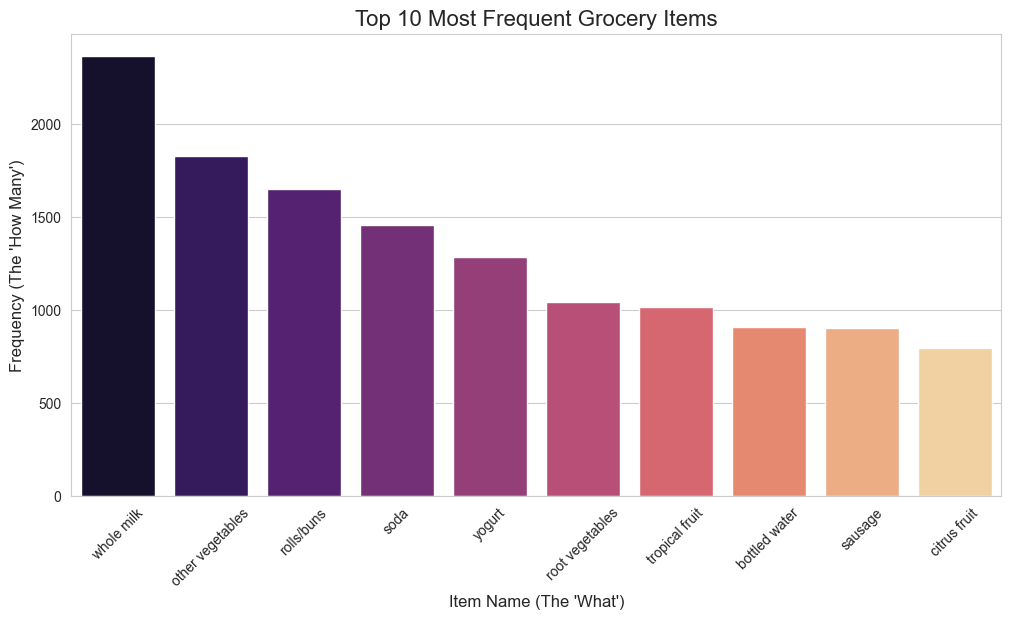

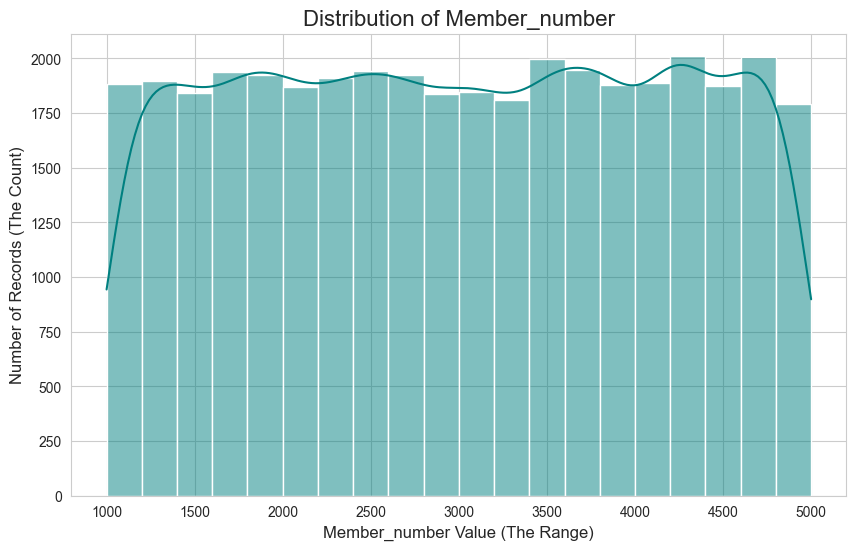

In [22]:
# --- Task 3: Explore Data (Distributions) ---

# 1. CATEGORICAL DATA: What are the top selling items?
# We select the top 10 most frequent items to keep the graph "Clean"
top_items = df['itemDescription'].value_counts().head(10) # Replace 'itemDescription' with your column name

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.index, y=top_items.values, palette='magma')

# ADDING CLEAR LABELS
plt.title("Top 10 Most Frequent Grocery Items", fontsize=16)
plt.xlabel("Item Name (The 'What')", fontsize=12)
plt.ylabel("Frequency (The 'How Many')", fontsize=12)
plt.xticks(rotation=45) # Tilts the text so it doesn't overlap
plt.show()

# 2. NUMERICAL DATA: How are the values spread out?
# If you have a 'Price' or 'Quantity' column, we use a Histogram
numerical_cols = df.select_dtypes(include=['number']).columns

if len(numerical_cols) > 0:
    # We take the first numerical column found
    col_to_plot = numerical_cols[0] 
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col_to_plot], bins=20, kde=True, color='teal')
    
    plt.title(f"Distribution of {col_to_plot}", fontsize=16)
    plt.xlabel(f"{col_to_plot} Value (The Range)", fontsize=12)
    plt.ylabel("Number of Records (The Count)", fontsize=12)
    plt.show()
else:
    print("No numerical columns found to plot.")

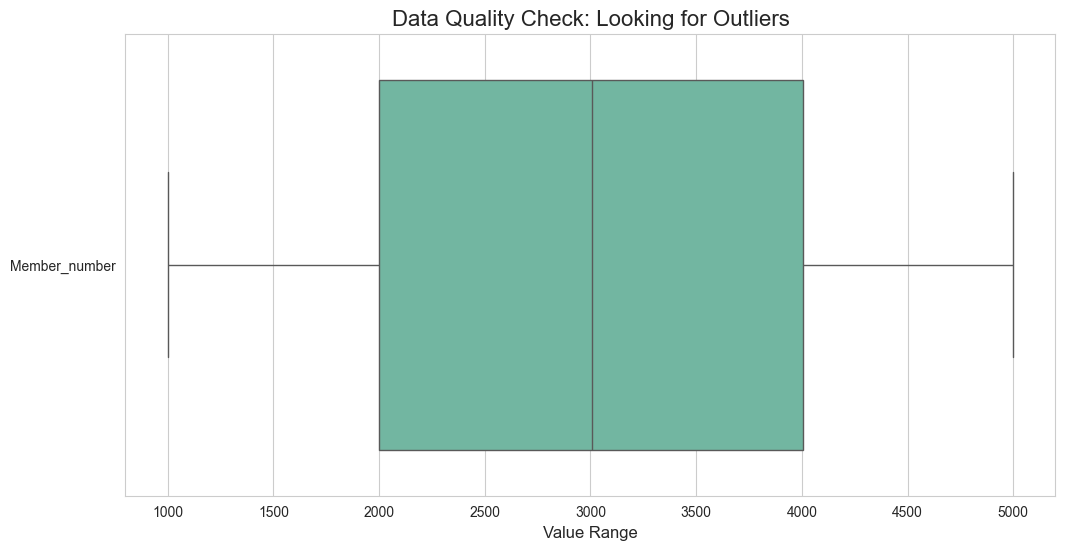

In [23]:
# --- Task 4: Verify Data Quality (Simple Box Plot) ---

# We only look at numerical columns like 'Member_Number' or 'Quantity'
num_cols = df.select_dtypes(include=['number']).columns

if len(num_cols) > 0:
    plt.figure(figsize=(12, 6))
    
    # We plot the distribution of our numbers
    sns.boxplot(data=df[num_cols], orient="h", palette="Set2")

    # EXPLANATION:
    # X-Axis: The range of values for that variable.
    # The 'Box': Where the middle 50% of your data lives.
    # The 'Whiskers': The normal range of the data.
    # The 'Dots': These are OUTLIERS (Data points that are very unusual).
    
    plt.title("Data Quality Check: Looking for Outliers", fontsize=16)
    plt.xlabel("Value Range", fontsize=12)
    plt.show()
else:
    print("No numerical data found for box plots.")